# Sentiment Analysis Project — Clean Training Notebook

This notebook:
1. Loads the dataset.
2. Cleans the text and sentiment labels.
3. Splits the data into training and testing sets.
4. Converts text into TF-IDF features.
5. Trains Logistic Regression, Naive Bayes, SVM, and XGBoost.
6. Compares their accuracy.
7. Saves the **XGBoost model + TF-IDF vectorizer + label encoder** for Streamlit deployment.

**Important:** Run the cells from top to bottom in a fresh Colab runtime.

In [3]:
# Install required packages
!pip install -q xgboost joblib

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load the dataset

Upload `test.csv` to Colab, or change the path below if your CSV has a different name.

In [5]:
# Load dataset
DATA_PATH = "/content/test.csv"

df = pd.read_csv(DATA_PATH, encoding="latin1")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())

df.head()

Rows: 4815
Columns: 9

Columns:
['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


## 2. Standardize the important columns

Your original notebook mixed `Text`/`text` and `Sentiment`/`sentiment`. This cell makes the notebook use one consistent naming scheme.

In [6]:
# Find text and sentiment columns regardless of capitalization
column_lookup = {str(col).strip().lower(): col for col in df.columns}

text_col = column_lookup.get("text")
sentiment_col = column_lookup.get("sentiment")

if text_col is None or sentiment_col is None:
    raise ValueError(
        "The dataset must contain columns named 'text' and 'sentiment' "
        "(capitalization does not matter)."
    )

# Keep only the two columns needed for text sentiment classification
df = df[[text_col, sentiment_col]].copy()
df.columns = ["text", "sentiment"]

# Convert to strings and remove extra spaces
df["text"] = df["text"].astype(str).str.strip()
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

# Remove missing/empty values and duplicate rows
df = df.replace({"": np.nan, "nan": np.nan})
df = df.dropna(subset=["text", "sentiment"])
df = df.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("\nSentiment classes:")
print(df["sentiment"].value_counts())

df.head()

Cleaned shape: (3533, 2)

Sentiment classes:
sentiment
neutral     1430
positive    1103
negative    1000
Name: count, dtype: int64


,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely --...,positive
2,"Recession hit Veronique Branquinho, she has to...",negative
3,happy bday!,positive
4,http://twitpic.com/4w75p - I like it!!,positive


In [7]:
# Keep the standard 3 sentiment classes for this project
allowed_sentiments = {"positive", "negative", "neutral"}

df = df[df["sentiment"].isin(allowed_sentiments)].reset_index(drop=True)

if df["sentiment"].nunique() < 2:
    raise ValueError("The dataset needs at least two sentiment classes.")

print("Final shape:", df.shape)
print(df["sentiment"].value_counts())

Final shape: (3533, 2)
sentiment
neutral     1430
positive    1103
negative    1000
Name: count, dtype: int64


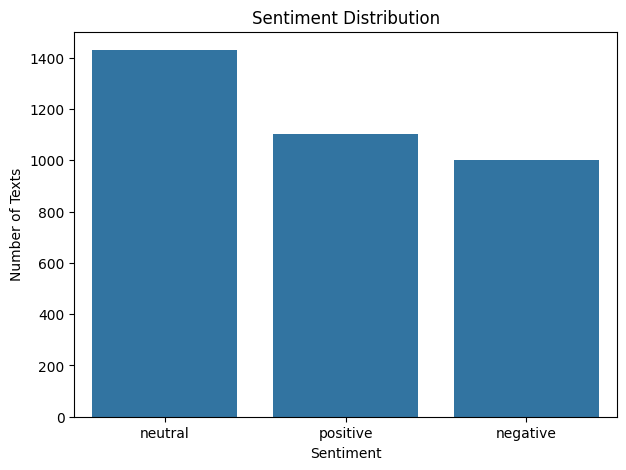

In [8]:
# Sentiment distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")
plt.show()

## 3. Text cleaning

In [9]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

# Remove rows that became empty after cleaning
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

df[["text", "clean_text", "sentiment"]].head()

,text,clean_text,sentiment
0,Last session of the day http://twitpic.com/67ezh,last session of the day,neutral
1,Shanghai is also really exciting (precisely --...,shanghai is also really exciting precisely sky...,positive
2,"Recession hit Veronique Branquinho, she has to...",recession hit veronique branquinho she has to ...,negative
3,happy bday!,happy bday,positive
4,http://twitpic.com/4w75p - I like it!!,i like it,positive


## 4. Train/test split

In [10]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2825
Testing samples: 707


## 5. TF-IDF vectorization

In [11]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (2825, 4866)
Testing TF-IDF shape: (707, 4866)


## 6. Logistic Regression

In [12]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.6223
              precision    recall  f1-score   support

    negative       0.65      0.48      0.55       200
     neutral       0.54      0.73      0.62       286
    positive       0.77      0.61      0.68       221

    accuracy                           0.62       707
   macro avg       0.66      0.61      0.62       707
weighted avg       0.65      0.62      0.62       707



## 7. Naive Bayes

In [13]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_predictions)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 0.5785
              precision    recall  f1-score   support

    negative       0.74      0.28      0.40       200
     neutral       0.50      0.84      0.63       286
    positive       0.76      0.51      0.61       221

    accuracy                           0.58       707
   macro avg       0.67      0.54      0.55       707
weighted avg       0.65      0.58      0.56       707



## 8. SVM

In [14]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(classification_report(y_test, svm_predictions))

SVM Accuracy: 0.6096
              precision    recall  f1-score   support

    negative       0.62      0.58      0.60       200
     neutral       0.55      0.60      0.58       286
    positive       0.69      0.64      0.67       221

    accuracy                           0.61       707
   macro avg       0.62      0.61      0.61       707
weighted avg       0.61      0.61      0.61       707



## 9. XGBoost

XGBoost needs numeric class labels, so we use `LabelEncoder`. The same encoder is saved and will be used by Streamlit.

In [15]:
# Encode sentiment labels for XGBoost
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Encoded classes:")
for number, label in enumerate(label_encoder.classes_):
    print(number, "=", label)

Encoded classes:
0 = negative
1 = neutral
2 = positive


In [16]:
# Train XGBoost
num_classes = len(label_encoder.classes_)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train_tfidf, y_train_encoded)

xgb_predictions = xgb_model.predict(X_test_tfidf)
xgb_predictions = xgb_predictions.astype(int)

xgb_accuracy = accuracy_score(y_test_encoded, xgb_predictions)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(classification_report(
    y_test_encoded,
    xgb_predictions,
    target_names=label_encoder.classes_
))

XGBoost Accuracy: 0.6195
              precision    recall  f1-score   support

    negative       0.72      0.36      0.48       200
     neutral       0.53      0.82      0.64       286
    positive       0.79      0.60      0.68       221

    accuracy                           0.62       707
   macro avg       0.68      0.59      0.60       707
weighted avg       0.67      0.62      0.61       707



## 10. Compare all models

In [17]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy,
        xgb_accuracy
    ]
})

results = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
results

,Model,Accuracy
0,Logistic Regression,0.622348
1,XGBoost,0.619519
2,SVM,0.609618
3,Naive Bayes,0.578501


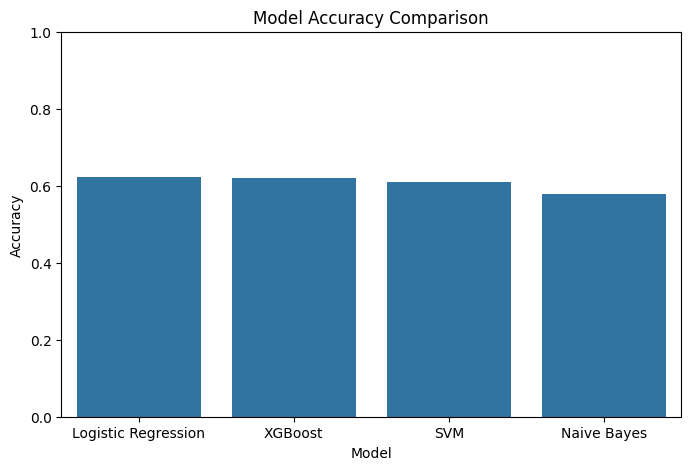

Best model: Logistic Regression
Best accuracy: 0.6223


In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

print("Best model:", results.loc[0, "Model"])
print("Best accuracy:", round(results.loc[0, "Accuracy"], 4))

## 11. XGBoost confusion matrix

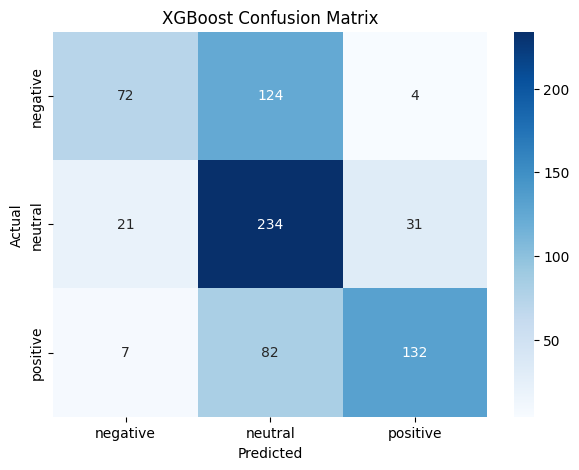

In [19]:
cm = confusion_matrix(y_test_encoded, xgb_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

## 12. Test a new sentence

In [20]:
def predict_sentiment(review):
    cleaned = clean_text(review)
    vectorized = vectorizer.transform([cleaned])

    encoded_prediction = int(xgb_model.predict(vectorized)[0])
    prediction = label_encoder.inverse_transform([encoded_prediction])[0]

    probabilities = xgb_model.predict_proba(vectorized)[0]
    confidence = float(np.max(probabilities) * 100)

    return prediction, confidence

examples = [
    "I absolutely love this product!",
    "This product is terrible and I hate it.",
    "The product arrived yesterday."
]

for review in examples:
    prediction, confidence = predict_sentiment(review)
    print(f"Text: {review}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 50)

Text: I absolutely love this product!
Prediction: positive
Confidence: 86.15%
--------------------------------------------------
Text: This product is terrible and I hate it.
Prediction: negative
Confidence: 70.75%
--------------------------------------------------
Text: The product arrived yesterday.
Prediction: neutral
Confidence: 53.55%
--------------------------------------------------


## 13. Save the files for Streamlit

After running this cell, download these **three files** from Colab and upload them to the same GitHub repository as `app.py`:

- `xgb_model.json`
- `tfidf_vectorizer.joblib`
- `label_encoder.joblib`

These three files must be created from the **same training run**.

In [21]:
# Save XGBoost model in JSON format
xgb_model.save_model("xgb_model.json")

# Save the exact TF-IDF vectorizer used during training
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")

# Save the exact label encoder used during XGBoost training
joblib.dump(label_encoder, "label_encoder.joblib")

print("Saved successfully:")
print("1. xgb_model.json")
print("2. tfidf_vectorizer.joblib")
print("3. label_encoder.joblib")

Saved successfully:
1. xgb_model.json
2. tfidf_vectorizer.joblib
3. label_encoder.joblib


## 14. Verify the saved files

In [22]:
import os

required_files = [
    "xgb_model.json",
    "tfidf_vectorizer.joblib",
    "label_encoder.joblib"
]

for file_name in required_files:
    print(file_name, "->", "OK" if os.path.exists(file_name) else "MISSING")

xgb_model.json -> OK
tfidf_vectorizer.joblib -> OK
label_encoder.joblib -> OK
